Batch: 1
X shape: torch.Size([144, 1, 128])
y shape: torch.Size([144])
Epoch 1, Avg Loss: 1.10319036
Accuracy on test set: 32 %
Accuracy on new test set: 35 %
Epoch 2, Avg Loss: 1.09911105
Accuracy on test set: 34 %
Accuracy on new test set: 34 %
Epoch 3, Avg Loss: 1.09710574
Accuracy on test set: 36 %
Accuracy on new test set: 35 %
Epoch 4, Avg Loss: 1.09279373
Accuracy on test set: 36 %
Accuracy on new test set: 36 %
Epoch 5, Avg Loss: 1.09138703
Accuracy on test set: 37 %
Accuracy on new test set: 37 %
Epoch 6, Avg Loss: 1.08991492
Accuracy on test set: 36 %
Accuracy on new test set: 36 %
Epoch 7, Avg Loss: 1.08838347
Accuracy on test set: 39 %
Accuracy on new test set: 38 %
Epoch 8, Avg Loss: 1.08467588
Accuracy on test set: 38 %
Accuracy on new test set: 37 %
Epoch 9, Avg Loss: 1.08294958
Accuracy on test set: 41 %
Accuracy on new test set: 43 %
Epoch 10, Avg Loss: 1.07941058
Accuracy on test set: 40 %
Accuracy on new test set: 43 %
Epoch 11, Avg Loss: 1.07586566
Accuracy on test 

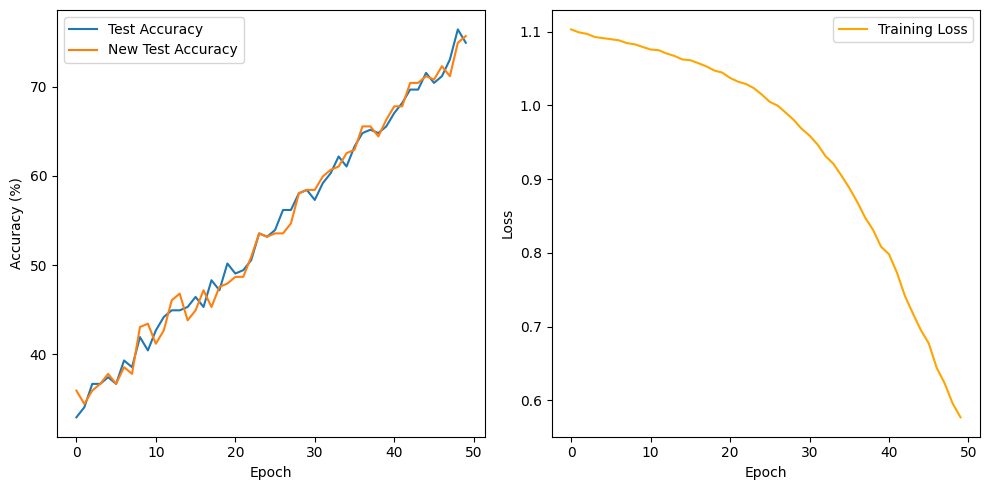

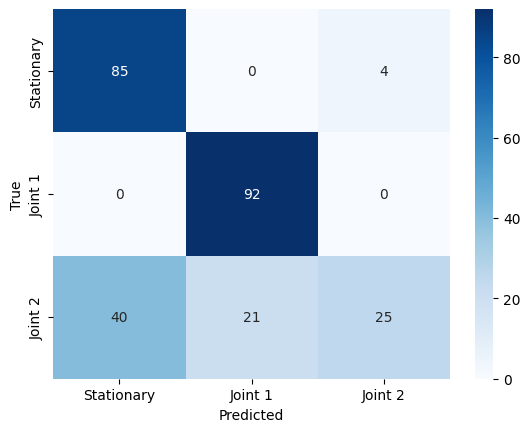

              precision    recall  f1-score   support

  Stationary       0.69      0.92      0.79        89
     Joint 1       0.79      1.00      0.88        92
     Joint 2       0.79      0.30      0.44        86

    accuracy                           0.75       267
   macro avg       0.76      0.74      0.70       267
weighted avg       0.76      0.75      0.71       267


Training with learning rate: 0.001
Epoch 1, Avg Loss: 1.09326634
Accuracy on test set: 37 %
Epoch 2, Avg Loss: 1.09166861
Accuracy on test set: 39 %
Epoch 3, Avg Loss: 1.09340778
Accuracy on test set: 41 %
Epoch 4, Avg Loss: 1.09265509
Accuracy on test set: 38 %
Epoch 5, Avg Loss: 1.09137452
Accuracy on test set: 40 %
Epoch 6, Avg Loss: 1.08887559
Accuracy on test set: 39 %
Epoch 7, Avg Loss: 1.09067002
Accuracy on test set: 37 %
Epoch 8, Avg Loss: 1.08941287
Accuracy on test set: 39 %
Epoch 9, Avg Loss: 1.08768341
Accuracy on test set: 40 %
Epoch 10, Avg Loss: 1.08894378
Accuracy on test set: 38 %

Training wi

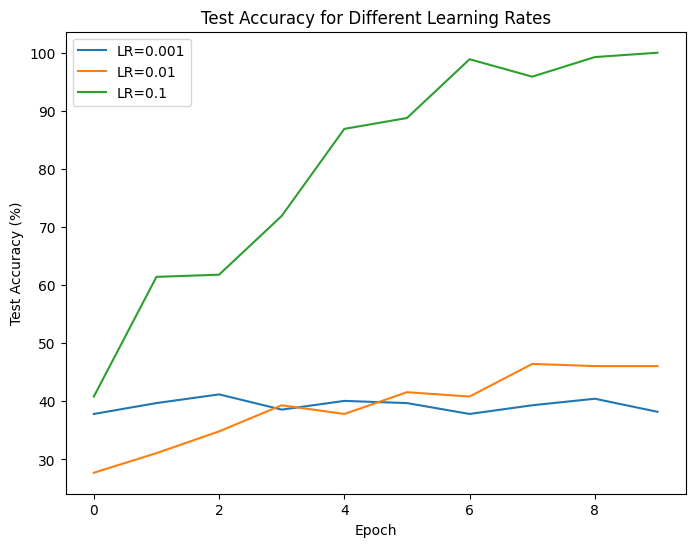

In [ ]:
import math #CNN
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
import torch
from torch import nn
from torch import optim
import random
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import warnings
warnings.filterwarnings("ignore")

# Convert data to torch tensors
class Data(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X.astype(np.float32))
        self.y = torch.from_numpy(y.astype(np.float32))
        self.len = self.X.shape[0]

    def __getitem__(self, index):
        return self.X[index].reshape((1, 128)), self.y[index].long()

    def __len__(self):
        return self.len

class Flatten(torch.nn.Module):
    def forward(self, x):
        batch_size = x.shape[0]
        return x.view(batch_size, -1)

class classifier(nn.Module):
    def __init__(self, in_channels=1):
        super(classifier, self).__init__()
        self.sq1 = nn.Sequential(
            nn.Conv1d(1, 128, 5, stride=1),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.MaxPool1d(kernel_size=2, stride=3),)
        self.sq2 = nn.Sequential(
            nn.Conv1d(128, 32, 5, stride=1),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.MaxPool1d(2, stride=2),)
        self.sq4 = nn.Sequential(
            nn.Conv1d(32, 32, 2, stride=2),
            nn.ReLU(),
            nn.MaxPool1d(2, stride=2),)
        self.sq5 = nn.Sequential(
            nn.Conv1d(32, 128, 2, stride=1),
            Flatten(),)
        self.sq7 = nn.Sequential(
            nn.Linear(in_features=384, out_features=128),
            nn.ReLU(),
            nn.Dropout(p=.1),
            nn.Linear(in_features=128, out_features=3),
        )

    def forward(self, x, ex_features=None):
        out = self.sq1(x)
        out = self.sq2(out)
        out = self.sq4(out)
        out = self.sq5(out)
        out = self.sq7(out)
        return out

def feature_extraction(df, length, overlap):
    processed_df = []
    i = 0
    while i < (len(df) - length):
        if i % math.floor(length * (1 - overlap)) == 0:
            # feature extracted from the horizontal signal
            features = []
            signal = df['y'][i:i + length]
            features.extend(signal)
            processed_df.append(features)
        i = i + 1
    processed_df = np.array(processed_df)
    return processed_df

def setup_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True

# Setting random seeds
setup_seed(11)

# Divide tables into data samples
data_length = 128
overlap_rate = 0.97
batch_size = 144

# Load data from csv files
joint_1_table = pd.read_csv('2t.csv', header=0)
joint_2_table = pd.read_csv('5t.csv', header=0)
stationary_table = pd.read_csv('air.csv', header=0)

joint_1_x = feature_extraction(joint_1_table, data_length, overlap_rate)
joint_2_x = feature_extraction(joint_2_table, data_length, overlap_rate)
stationary_x = feature_extraction(stationary_table, data_length, overlap_rate)
X = np.concatenate((stationary_x, joint_1_x, joint_2_x), axis=0)
y = np.concatenate((np.zeros(len(stationary_x)), np.ones(len(joint_1_x)), np.full(len(joint_2_x), 2)), axis=0)
y = y.astype(np.int64)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.33, random_state=26)

# Instantiate training and test data
train_data = Data(X_train, y_train)
train_dataloader = DataLoader(dataset=train_data, batch_size=batch_size, shuffle=True)

test_data = Data(X_test, y_test)
test_dataloader = DataLoader(dataset=test_data, batch_size=batch_size, shuffle=True)

# Load data from csv files
joint_1_table_new = pd.read_csv('2tnew.csv', header=0)
joint_2_table_new = pd.read_csv('5tnew.csv', header=0)
stationary_table_new = pd.read_csv('airnew.csv', header=0)

joint_1_x_new = feature_extraction(joint_1_table_new, data_length, overlap_rate)
joint_2_x_new = feature_extraction(joint_2_table_new, data_length, overlap_rate)
stationary_x_new = feature_extraction(stationary_table_new, data_length, overlap_rate)
X_new = np.concatenate((stationary_x_new, joint_1_x_new, joint_2_x_new), axis=0)
y_new = np.concatenate((np.zeros(len(stationary_x_new)), np.ones(len(joint_1_x_new)), np.full(len(joint_2_x_new), 2)), axis=0)
y_new = y_new.astype(np.int64)
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_new, y_new, test_size=.33, random_state=26)

# Instantiate training and test data
train_data_new = Data(X_train_new, y_train_new)
train_dataloader_new = DataLoader(dataset=train_data_new, batch_size=batch_size, shuffle=True)

test_data_new = Data(X_test_new, y_test_new)
test_dataloader_new = DataLoader(dataset=test_data_new, batch_size=batch_size, shuffle=True)

# Check it's working
for batch, (X, y) in enumerate(train_dataloader):
    print(f"Batch: {batch + 1}")
    print(f"X shape: {X.shape}")
    print(f"y shape: {y.shape}")
    break

# Initialize model, loss, and optimizer
model = classifier()
criterion = torch.nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)  # Original learning rate

# Lists to store metrics
train_losses = []
correct_list = []

def train(epoch):
    running_loss = 0.0
    for batch_idx, data in enumerate(train_dataloader, 0):
        inputs, target = data
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, target)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        if batch_idx % 10 == 9:
            print('[%d, %5d] loss: %.8f' % (epoch + 1, batch_idx + 1, running_loss / 300))
            running_loss = 0.0
    # Store the average loss for the epoch
    avg_loss = running_loss / len(train_dataloader)
    train_losses.append(avg_loss)
    print(f'Epoch {epoch + 1}, Avg Loss: {avg_loss:.8f}')

def test():
    correct = 0
    total = 0
    with torch.no_grad():
        for data in test_dataloader:
            inputs, labels = data
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, dim=1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = 100 * correct / total
    correct_list.append(accuracy)
    print('Accuracy on test set: %d %%' % accuracy)

def test_new():
    correct = 0
    total = 0
    with torch.no_grad():
        for data in test_dataloader_new:
            inputs, labels = data
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, dim=1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = 100 * correct / total
    correct_list.append(accuracy)
    print('Accuracy on new test set: %d %%' % accuracy)

# Original training loop (50 epochs with single learning rate)
for epoch in range(50):
    train(epoch)
    test()
    test_new()

# Plot accuracy and loss together
plt.figure(figsize=(10, 5))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(correct_list[::2], label='Test Accuracy')
plt.plot(correct_list[1::2], label='New Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(train_losses, label='Training Loss', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

def test_with_confusion():
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for data in test_dataloader:
            inputs, labels = data
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, dim=1)
            all_preds.extend(predicted.numpy())
            all_labels.extend(labels.numpy())
    cm = confusion_matrix(all_labels, all_preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Stationary', 'Joint 1', 'Joint 2'], yticklabels=['Stationary', 'Joint 1', 'Joint 2'])
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

test_with_confusion()

# Classification report
from sklearn.metrics import classification_report

def test_with_metrics():
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for data in test_dataloader:
            inputs, labels = data
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, dim=1)
            all_preds.extend(predicted.numpy())
            all_labels.extend(labels.numpy())
    print(classification_report(all_labels, all_preds, target_names=['Stationary', 'Joint 1', 'Joint 2']))

test_with_metrics()

# Experiment with different learning rates
learning_rates = [0.001, 0.01, 0.1]  # Define learning rates to test
all_correct_lists = []  # To store accuracy lists for each learning rate

for lr in learning_rates:
    print(f"\nTraining with learning rate: {lr}")
    model = classifier()  # Reinitialize model
    optimizer = optim.SGD(model.parameters(), lr=lr)
    correct_list = []  # Reset for this learning rate
    train_losses = []  # Reset for this learning rate

    for epoch in range(10):  # Fewer epochs for quick testing
        train(epoch)
        test()
        # Optionally include test_new() if you want new test set accuracies
        # test_new()

    all_correct_lists.append(correct_list)

# Plot accuracies for different learning rates
plt.figure(figsize=(8, 6))
for i, lr in enumerate(learning_rates):
    plt.plot(all_correct_lists[i], label=f'LR={lr}')
plt.xlabel('Epoch')
plt.ylabel('Test Accuracy (%)')
plt.title('Test Accuracy for Different Learning Rates')
plt.legend()
plt.show()

Batch: 1
X shape: torch.Size([36, 1, 128])
y shape: torch.Size([36])
Epoch 1, Avg Loss: 1.02676632
Accuracy on test set: 20.90 %
Accuracy on new test set: 20.90 %
Epoch 2, Avg Loss: 0.63177199
Accuracy on test set: 43.28 %
Accuracy on new test set: 43.28 %
Epoch 3, Avg Loss: 0.35204772
Accuracy on test set: 46.27 %
Accuracy on new test set: 46.27 %
Epoch 4, Avg Loss: 0.20666168
Accuracy on test set: 61.94 %
Accuracy on new test set: 61.94 %
Epoch 5, Avg Loss: 0.07605039
Accuracy on test set: 94.03 %
Accuracy on new test set: 94.03 %
Epoch 6, Avg Loss: 0.06694764
Accuracy on test set: 99.25 %
Accuracy on new test set: 99.25 %
Epoch 7, Avg Loss: 0.02765020
Accuracy on test set: 100.00 %
Accuracy on new test set: 100.00 %
Epoch 8, Avg Loss: 0.01796316
Accuracy on test set: 100.00 %
Accuracy on new test set: 100.00 %
Epoch 9, Avg Loss: 0.01990632
Accuracy on test set: 98.51 %
Accuracy on new test set: 98.51 %
Epoch 10, Avg Loss: 0.01533283
Accuracy on test set: 100.00 %
Accuracy on new tes

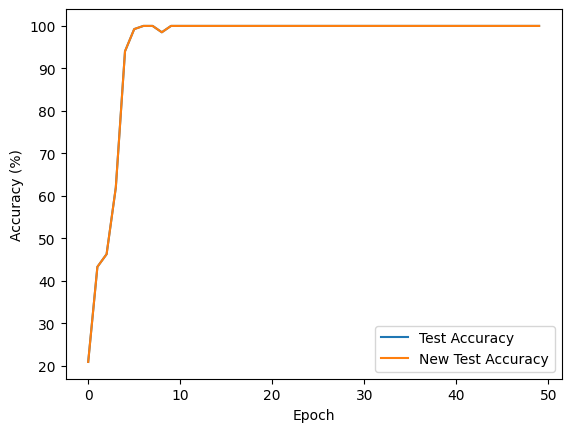

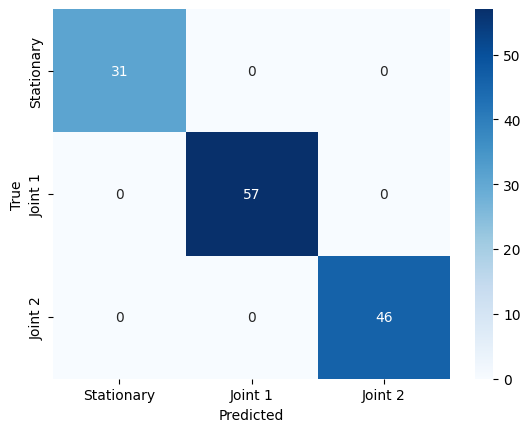

              precision    recall  f1-score   support

  Stationary       1.00      1.00      1.00        31
     Joint 1       1.00      1.00      1.00        57
     Joint 2       1.00      1.00      1.00        46

    accuracy                           1.00       134
   macro avg       1.00      1.00      1.00       134
weighted avg       1.00      1.00      1.00       134

Epoch 1, Avg Loss: 0.00677818
Accuracy on test set: 100.00 %
Accuracy on new test set: 100.00 %
Epoch 2, Avg Loss: 0.00986264
Accuracy on test set: 100.00 %
Accuracy on new test set: 100.00 %
Epoch 3, Avg Loss: 0.00849207
Accuracy on test set: 100.00 %
Accuracy on new test set: 100.00 %
Epoch 4, Avg Loss: 0.00650397
Accuracy on test set: 100.00 %
Accuracy on new test set: 100.00 %
Epoch 5, Avg Loss: 0.01096768
Accuracy on test set: 100.00 %
Accuracy on new test set: 100.00 %
Epoch 6, Avg Loss: 0.01079437
Accuracy on test set: 100.00 %
Accuracy on new test set: 100.00 %
Epoch 7, Avg Loss: 0.00820088
Accuracy on t

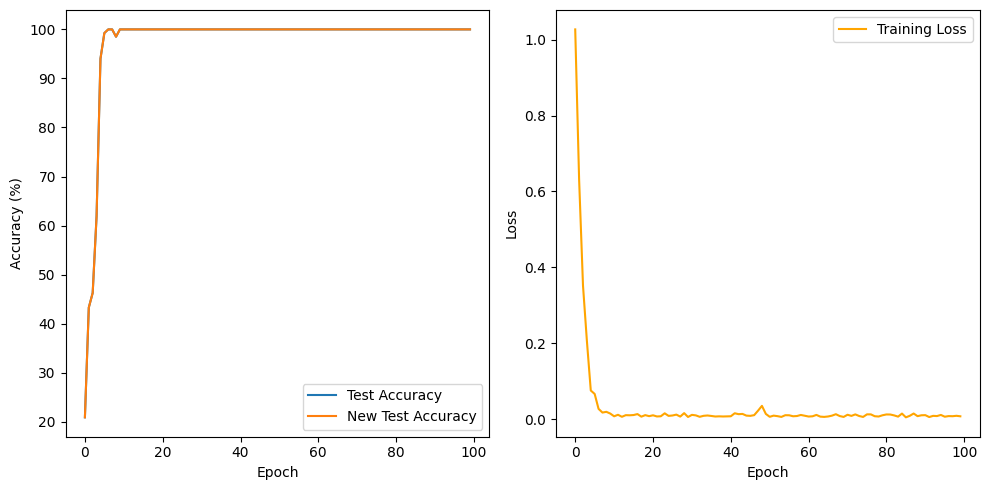

Epoch 1, Avg Loss: 0.58090369
Accuracy on test set: 43.28 %
Epoch 2, Avg Loss: 0.12682877
Accuracy on test set: 48.51 %
Epoch 3, Avg Loss: 0.02801412
Accuracy on test set: 58.21 %
Epoch 4, Avg Loss: 0.02423105
Accuracy on test set: 93.28 %
Epoch 5, Avg Loss: 0.01051717
Accuracy on test set: 96.27 %
Epoch 6, Avg Loss: 0.00359086
Accuracy on test set: 100.00 %
Epoch 7, Avg Loss: 0.00213907
Accuracy on test set: 100.00 %
Epoch 8, Avg Loss: 0.00569690
Accuracy on test set: 100.00 %
Epoch 9, Avg Loss: 0.00544893
Accuracy on test set: 100.00 %
Epoch 10, Avg Loss: 0.00247831
Accuracy on test set: 100.00 %
Epoch 1, Avg Loss: 1.29801761
Accuracy on test set: 23.13 %
Epoch 2, Avg Loss: 0.47852790
Accuracy on test set: 23.13 %
Epoch 3, Avg Loss: 0.21557968
Accuracy on test set: 21.64 %
Epoch 4, Avg Loss: 0.29156472
Accuracy on test set: 85.07 %
Epoch 5, Avg Loss: 0.13369316
Accuracy on test set: 82.84 %
Epoch 6, Avg Loss: 0.13450030
Accuracy on test set: 89.55 %
Epoch 7, Avg Loss: 0.08802623
Accu

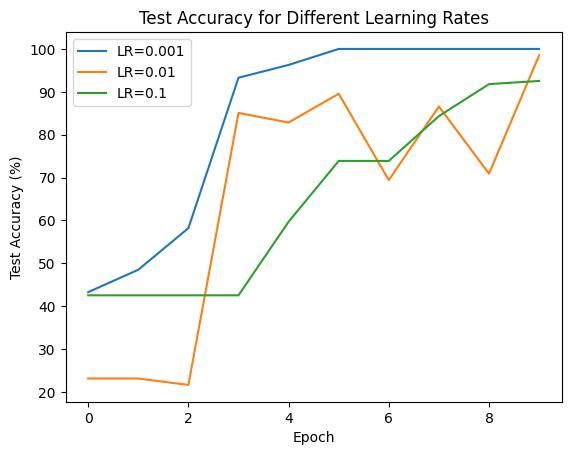

In [ ]:
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch
from torch import nn
from torch import optim
import random
from torch.utils.data import Dataset, DataLoader
import warnings
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
warnings.filterwarnings("ignore")

# Convert data to torch tensors
class Data(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X.astype(np.float32))  # Shape: (n_samples, 128)
        self.y = torch.from_numpy(y.astype(np.float32))
        self.len = self.X.shape[0]

    def __getitem__(self, index):
        return self.X[index].reshape(1, 128), self.y[index].long()  # Shape: (1, 128) for 1D CNN

    def __len__(self):
        return self.len

# Residual Block for 1D ResNet
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm1d(out_channels)
        self.downsample = downsample  # For adjusting dimensions in skip connection

    def forward(self, x):
        identity = x  # Save input for skip connection
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        if self.downsample is not None:
            identity = self.downsample(x)  # Adjust identity if dimensions differ
        out += identity  # Add skip connection
        out = self.relu(out)
        return out

# ResNet-inspired 1D Classifier
class ResNet1D(nn.Module):
    def __init__(self, in_channels=1, num_classes=3):
        super(ResNet1D, self).__init__()
        self.initial_conv = nn.Sequential(
            nn.Conv1d(in_channels, 64, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=3, stride=2, padding=1)
        )
        self.layer1 = self._make_layer(64, 64, num_blocks=2, stride=1)
        self.layer2 = self._make_layer(64, 128, num_blocks=2, stride=2)
        self.layer3 = self._make_layer(128, 256, num_blocks=2, stride=2)
        self.avg_pool = nn.AdaptiveAvgPool1d(1)  # Reduce to (batch, channels, 1)
        self.fc = nn.Linear(256, num_classes)

    def _make_layer(self, in_channels, out_channels, num_blocks, stride):
        downsample = None
        if stride != 1 or in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=1, stride=stride),
                nn.BatchNorm1d(out_channels)
            )
        layers = []
        layers.append(ResidualBlock(in_channels, out_channels, stride, downsample))
        for _ in range(1, num_blocks):
            layers.append(ResidualBlock(out_channels, out_channels))
        return nn.Sequential(*layers)

    def forward(self, x):
        out = self.initial_conv(x)  # Shape: (batch, 64, ~32)
        out = self.layer1(out)      # Shape: (batch, 64, ~32)
        out = self.layer2(out)      # Shape: (batch, 128, ~16)
        out = self.layer3(out)      # Shape: (batch, 256, ~8)
        out = self.avg_pool(out)    # Shape: (batch, 256, 1)
        out = out.view(out.size(0), -1)  # Flatten: (batch, 256)
        out = self.fc(out)          # Shape: (batch, 3)
        return out

def feature_extraction(df, length, overlap):
    processed_df = []
    i = 0
    while i < (len(df) - length):
        if i % math.floor(length * (1 - overlap)) == 0:
            features = []
            signal = df['y'][i:i + length]
            features.extend(signal)
            processed_df.append(features)
        i = i + 1
    processed_df = np.array(processed_df)
    return processed_df

def setup_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True

# Setting random seeds
setup_seed(11)

# Divide tables into data samples
data_length = 128
overlap_rate = 0.95
batch_size = 36

# Load data from csv files
joint_1_table = pd.read_csv('2t.csv', header=0)
joint_2_table = pd.read_csv('5t.csv', header=0)
stationary_table = pd.read_csv('air.csv', header=0)

joint_1_x = feature_extraction(joint_1_table, data_length, overlap_rate)
joint_2_x = feature_extraction(joint_2_table, data_length, overlap_rate)
stationary_x = feature_extraction(stationary_table, data_length, overlap_rate)
X = np.concatenate((stationary_x, joint_1_x, joint_2_x), axis=0)
y = np.concatenate((np.zeros(len(stationary_x)), np.ones(len(joint_1_x)), np.full(len(joint_2_x), 2)), axis=0)
y = y.astype(np.int64)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=26)

# Instantiate training and test data
train_data = Data(X_train, y_train)
train_dataloader = DataLoader(dataset=train_data, batch_size=batch_size, shuffle=True)

test_data = Data(X_test, y_test)
test_dataloader = DataLoader(dataset=test_data, batch_size=batch_size, shuffle=True)

# Load new data from csv files
joint_1_table_new = pd.read_csv('2tnew.csv', header=0)
joint_2_table_new = pd.read_csv('5tnew.csv', header=0)
stationary_table_new = pd.read_csv('airnew.csv', header=0)

joint_1_x_new = feature_extraction(joint_1_table_new, data_length, overlap_rate)
joint_2_x_new = feature_extraction(joint_2_table_new, data_length, overlap_rate)
stationary_x_new = feature_extraction(stationary_table_new, data_length, overlap_rate)
X_new = np.concatenate((stationary_x_new, joint_1_x_new, joint_2_x_new), axis=0)
y_new = np.concatenate((np.zeros(len(stationary_x_new)), np.ones(len(joint_1_x_new)), np.full(len(joint_2_x_new), 2)), axis=0)
y_new = y_new.astype(np.int64)
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_new, y_new, test_size=0.33, random_state=26)

# Instantiate new training and test data
train_data_new = Data(X_train_new, y_train_new)
train_dataloader_new = DataLoader(dataset=train_data_new, batch_size=batch_size, shuffle=True)

test_data_new = Data(X_test_new, y_test_new)
test_dataloader_new = DataLoader(dataset=test_data_new, batch_size=batch_size, shuffle=True)

# Check data loading
for batch, (X, y) in enumerate(train_dataloader):
    print(f"Batch: {batch + 1}")
    print(f"X shape: {X.shape}")  # Should be (batch_size, 1, 128)
    print(f"y shape: {y.shape}")
    break

# Model, loss, and optimizer
model23 = ResNet1D(in_channels=1, num_classes=3)
criterion = torch.nn.CrossEntropyLoss()
optimizer = optim.Adam(model23.parameters(), lr=0.0001, betas=(0.9, 0.999), eps=1e-08, weight_decay=0.0)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

# Lists to store metrics
train_losses = []  # To store average loss per epoch
correct_list = []

def train(epoch):
    model23.train()
    running_loss = 0.0
    for batch_idx, data in enumerate(train_dataloader, 0):
        inputs, target = data  # inputs: (batch, 1, 128)
        optimizer.zero_grad()
        outputs = model23(inputs)
        loss = criterion(outputs, target)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        if batch_idx % 10 == 9:
            print('[%d, %5d] loss: %.8f' % (epoch + 1, batch_idx + 1, running_loss / 10))
            running_loss = 0.0
    # Store the average loss for the epoch
    avg_loss = running_loss / len(train_dataloader)
    train_losses.append(avg_loss)
    print(f'Epoch {epoch + 1}, Avg Loss: {avg_loss:.8f}')

def test():
    model23.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data in test_dataloader:
            inputs, labels = data
            outputs = model23(inputs)
            _, predicted = torch.max(outputs.data, dim=1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = 100 * correct / total
    correct_list.append(accuracy)
    print('Accuracy on test set: %.2f %%' % accuracy)

def test_new():
    model23.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data in test_dataloader_new:
            inputs, labels = data
            outputs = model23(inputs)
            _, predicted = torch.max(outputs.data, dim=1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = 100 * correct / total
    correct_list.append(accuracy)
    print('Accuracy on new test set: %.2f %%' % accuracy)

# Training loop
for epoch in range(50):
    train(epoch)
    test()
    test_new()
    scheduler.step()

plt.plot(correct_list[::2], label='Test Accuracy')  # Every even index is test set
plt.plot(correct_list[1::2], label='New Test Accuracy')  # Every odd index is new test set
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.show()

def test_with_confusion():
    model23.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for data in test_dataloader:
            inputs, labels = data
            outputs = model23(inputs)
            _, predicted = torch.max(outputs.data, dim=1)
            all_preds.extend(predicted.numpy())
            all_labels.extend(labels.numpy())
    cm = confusion_matrix(all_labels, all_preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Stationary', 'Joint 1', 'Joint 2'], yticklabels=['Stationary', 'Joint 1', 'Joint 2'])
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

test_with_confusion()

def test_with_metrics():
    model23.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for data in test_dataloader:
            inputs, labels = data
            outputs = model23(inputs)
            _, predicted = torch.max(outputs.data, dim=1)
            all_preds.extend(predicted.numpy())
            all_labels.extend(labels.numpy())
    print(classification_report(all_labels, all_preds, target_names=['Stationary', 'Joint 1', 'Joint 2']))

test_with_metrics()

# Training loop (unchanged except calling train)
for epoch in range(50):
    train(epoch)
    test()
    test_new()

# Plot accuracy and loss together
plt.figure(figsize=(10, 5))

# Plot accuracy (as in your original code)
plt.subplot(1, 2, 1)
plt.plot(correct_list[::2], label='Test Accuracy')
plt.plot(correct_list[1::2], label='New Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(train_losses, label='Training Loss', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Experiment with different learning rates
learning_rates = [0.001, 0.01, 0.1]  # Define learning rates for ResNet1D
all_correct_lists = []  # To store accuracy lists for each learning rate

for lr in learning_rates:
    model23 = ResNet1D(in_channels=1, num_classes=3)
    optimizer = optim.Adam(model23.parameters(), lr=lr, betas=(0.9, 0.999), eps=1e-08, weight_decay=0.0)
    correct_list = []
    train_losses = []  # Reset for this learning rate
    for epoch in range(10):  # Fewer epochs for quick testing
        train(epoch)
        test()
    all_correct_lists.append(correct_list)

for i, lr in enumerate(learning_rates):
    plt.plot(all_correct_lists[i], label=f'LR={lr}')
plt.xlabel('Epoch')
plt.ylabel('Test Accuracy (%)')
plt.title('Test Accuracy for Different Learning Rates')
plt.legend()
plt.show()

Batch: 1
X shape: torch.Size([144, 1, 128])
y shape: torch.Size([144])
Epoch 1, Avg Loss: 1.09494680
Accuracy on test set: 34 %
Accuracy on new test set: 34 %
Epoch 2, Avg Loss: 1.09206250
Accuracy on test set: 34 %
Accuracy on new test set: 34 %
Epoch 3, Avg Loss: 1.09064293
Accuracy on test set: 34 %
Accuracy on new test set: 34 %
Epoch 4, Avg Loss: 1.08954826
Accuracy on test set: 34 %
Accuracy on new test set: 34 %
Epoch 5, Avg Loss: 1.08849576
Accuracy on test set: 34 %
Accuracy on new test set: 34 %
Epoch 6, Avg Loss: 1.08782113
Accuracy on test set: 34 %
Accuracy on new test set: 34 %
Epoch 7, Avg Loss: 1.08722699
Accuracy on test set: 34 %
Accuracy on new test set: 34 %
Epoch 8, Avg Loss: 1.08619970
Accuracy on test set: 34 %
Accuracy on new test set: 34 %
Epoch 9, Avg Loss: 1.08518082
Accuracy on test set: 34 %
Accuracy on new test set: 34 %
Epoch 10, Avg Loss: 1.08397841
Accuracy on test set: 34 %
Accuracy on new test set: 34 %
Epoch 11, Avg Loss: 1.08435920
Accuracy on test 

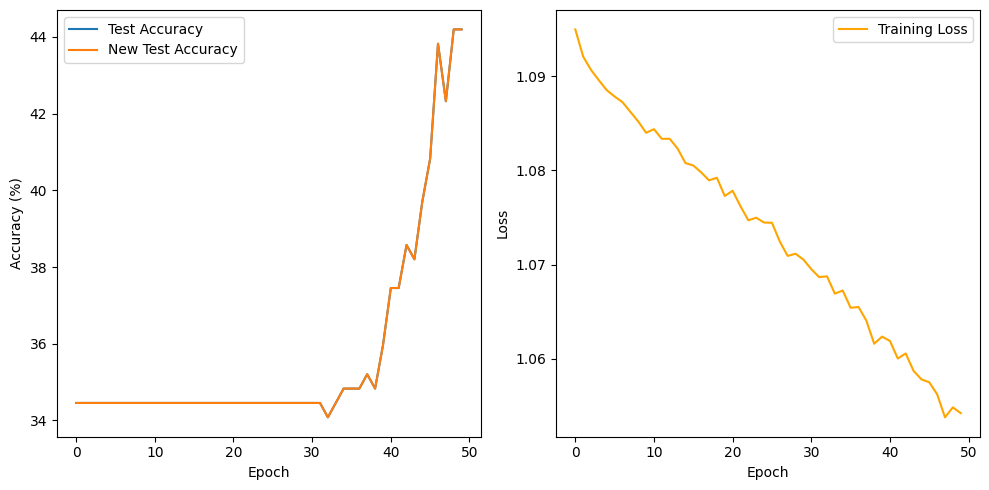

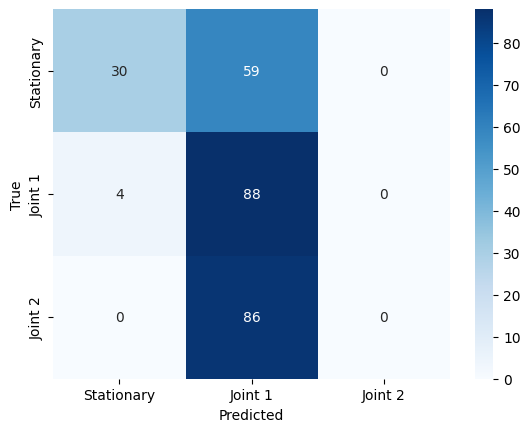

              precision    recall  f1-score   support

  Stationary       0.88      0.34      0.49        89
     Joint 1       0.38      0.96      0.54        92
     Joint 2       0.00      0.00      0.00        86

    accuracy                           0.44       267
   macro avg       0.42      0.43      0.34       267
weighted avg       0.42      0.44      0.35       267

Epoch 1, Avg Loss: 1.09474477
Accuracy on test set: 44 %
Epoch 2, Avg Loss: 1.09420228
Accuracy on test set: 44 %
Epoch 3, Avg Loss: 1.09318459
Accuracy on test set: 43 %
Epoch 4, Avg Loss: 1.09295729
Accuracy on test set: 49 %
Epoch 5, Avg Loss: 1.09213650
Accuracy on test set: 44 %
Epoch 6, Avg Loss: 1.09229234
Accuracy on test set: 50 %
Epoch 7, Avg Loss: 1.09128958
Accuracy on test set: 43 %
Epoch 8, Avg Loss: 1.09167284
Accuracy on test set: 49 %
Epoch 9, Avg Loss: 1.09094968
Accuracy on test set: 49 %
Epoch 10, Avg Loss: 1.09051737
Accuracy on test set: 50 %
Epoch 1, Avg Loss: 1.09681690
Accuracy on test s

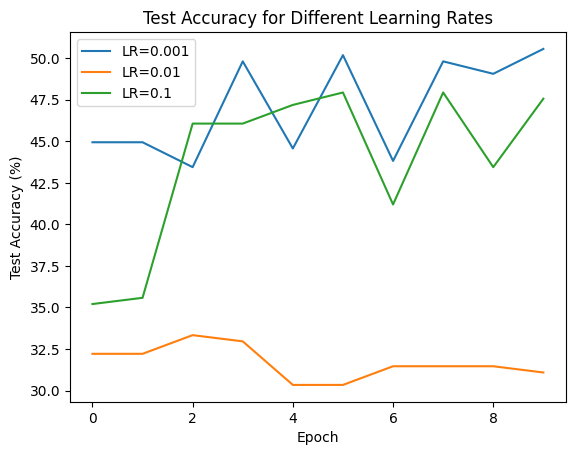

In [ ]:
import math #LSTM
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
import torch
from torch import nn
from torch import optim
import random
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import warnings
warnings.filterwarnings("ignore")

# Convert data to torch tensors
class Data(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X.astype(np.float32))
        self.y = torch.from_numpy(y.astype(np.float32))
        self.len = self.X.shape[0]

    def __getitem__(self, index):
        return self.X[index].reshape((1, 128)), self.y[index].long()

    def __len__(self):
        return self.len

# LSTM Classifier
class LSTMClassifier(nn.Module):
    def __init__(self, input_size=1, hidden_size=128, num_layers=2, num_classes=3):
        super(LSTMClassifier, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # x shape: (batch_size, 1, 128) -> (batch_size, 128, 1)
        x = x.transpose(1, 2)
        _, (hn, _) = self.lstm(x)  # hn: (num_layers, batch_size, hidden_size)
        out = self.fc(hn[-1])  # Take the last layer's hidden state
        return out

def feature_extraction(df, length, overlap):
    processed_df = []
    i = 0
    while i < (len(df) - length):
        if i % math.floor(length * (1 - overlap)) == 0:
            features = []
            signal = df['y'][i:i + length]
            features.extend(signal)
            processed_df.append(features)
        i = i + 1
    processed_df = np.array(processed_df)
    return processed_df

def setup_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True

# Setting random seeds
setup_seed(11)

# Divide tables into data samples
data_length = 128
overlap_rate = 0.97
batch_size = 144

# Load data from csv files
joint_1_table = pd.read_csv('2t.csv', header=0)
joint_2_table = pd.read_csv('5t.csv', header=0)
stationary_table = pd.read_csv('air.csv', header=0)

joint_1_x = feature_extraction(joint_1_table, data_length, overlap_rate)
joint_2_x = feature_extraction(joint_2_table, data_length, overlap_rate)
stationary_x = feature_extraction(stationary_table, data_length, overlap_rate)
X = np.concatenate((stationary_x, joint_1_x, joint_2_x), axis=0)
y = np.concatenate((np.zeros(len(stationary_x)), np.ones(len(joint_1_x)), np.full(len(joint_2_x), 2)), axis=0)
y = y.astype(np.int64)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.33, random_state=26)

# Instantiate training and test data
train_data = Data(X_train, y_train)
train_dataloader = DataLoader(dataset=train_data, batch_size=batch_size, shuffle=True)

test_data = Data(X_test, y_test)
test_dataloader = DataLoader(dataset=test_data, batch_size=batch_size, shuffle=True)

# Load new data
joint_1_table_new = pd.read_csv('2tnew.csv', header=0)
joint_2_table_new = pd.read_csv('5tnew.csv', header=0)
stationary_table_new = pd.read_csv('airnew.csv', header=0)

joint_1_x_new = feature_extraction(joint_1_table_new, data_length, overlap_rate)
joint_2_x_new = feature_extraction(joint_2_table_new, data_length, overlap_rate)
stationary_x_new = feature_extraction(stationary_table_new, data_length, overlap_rate)
X_new = np.concatenate((stationary_x_new, joint_1_x_new, joint_2_x_new), axis=0)
y_new = np.concatenate((np.zeros(len(stationary_x_new)), np.ones(len(joint_1_x_new)), np.full(len(joint_2_x_new), 2)), axis=0)
y_new = y_new.astype(np.int64)
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_new, y_new, test_size=.33, random_state=26)

train_data_new = Data(X_train_new, y_train_new)
train_dataloader_new = DataLoader(dataset=train_data_new, batch_size=batch_size, shuffle=True)

test_data_new = Data(X_test_new, y_test_new)
test_dataloader_new = DataLoader(dataset=test_data_new, batch_size=batch_size, shuffle=True)

# Check it's working
for batch, (X, y) in enumerate(train_dataloader):
    print(f"Batch: {batch + 1}")
    print(f"X shape: {X.shape}")
    print(f"y shape: {y.shape}")
    break

# Model, loss, and optimizer
model = LSTMClassifier(input_size=1, hidden_size=128, num_layers=2, num_classes=3)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

correct_list = []
train_losses = []

def train(epoch):
    running_loss = 0.0
    for batch_idx, data in enumerate(train_dataloader, 0):
        inputs, target = data
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, target)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        if batch_idx % 10 == 9:
            print('[%d, %5d] loss: %.8f' % (epoch + 1, batch_idx + 1, running_loss / 300))
            running_loss = 0.0
    avg_loss = running_loss / len(train_dataloader)
    train_losses.append(avg_loss)
    print(f'Epoch {epoch + 1}, Avg Loss: {avg_loss:.8f}')

def test():
    correct = 0
    total = 0
    with torch.no_grad():
        for data in test_dataloader:
            inputs, labels = data
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, dim=1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    correct_list.append(100 * correct / total)
    print('Accuracy on test set: %d %%' % (100 * correct / total))

def test_new():
    correct = 0
    total = 0
    with torch.no_grad():
        for data in test_dataloader_new:
            inputs, labels = data
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, dim=1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    correct_list.append(100 * correct / total)
    print('Accuracy on new test set: %d %%' % (100 * correct / total))

# Confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

def test_with_confusion():
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for data in test_dataloader:
            inputs, labels = data
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, dim=1)
            all_preds.extend(predicted.numpy())
            all_labels.extend(labels.numpy())
    cm = confusion_matrix(all_labels, all_preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Stationary', 'Joint 1', 'Joint 2'], yticklabels=['Stationary', 'Joint 1', 'Joint 2'])
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

# Classification report
from sklearn.metrics import classification_report

def test_with_metrics():
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for data in test_dataloader:
            inputs, labels = data
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, dim=1)
            all_preds.extend(predicted.numpy())
            all_labels.extend(labels.numpy())
    print(classification_report(all_labels, all_preds, target_names=['Stationary', 'Joint 1', 'Joint 2']))

# Training loop
for epoch in range(50):
    train(epoch)
    test()
    test_new()

# Plot accuracy and loss
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(correct_list[::2], label='Test Accuracy')
plt.plot(correct_list[1::2], label='New Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(train_losses, label='Training Loss', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

test_with_confusion()
test_with_metrics()

# Learning rate experiment
learning_rates = [0.001, 0.01, 0.1]
all_correct_lists = []

for lr in learning_rates:
    model = LSTMClassifier(input_size=1, hidden_size=128, num_layers=2, num_classes=3)
    optimizer = optim.SGD(model.parameters(), lr=lr)
    correct_list = []
    for epoch in range(10):
        train(epoch)
        test()
    all_correct_lists.append(correct_list)

for i, lr in enumerate(learning_rates):
    plt.plot(all_correct_lists[i], label=f'LR={lr}')
plt.xlabel('Epoch')
plt.ylabel('Test Accuracy (%)')
plt.title('Test Accuracy for Different Learning Rates')
plt.legend()
plt.show()


Loading original dataset...
Loading new dataset...
Batch 1: X shape = torch.Size([144, 1, 128]), y shape = torch.Size([144])

Training with single learning rate (0.01)...
Test Accuracy: 26.97% | Loss: 1.097692
New Test Accuracy: 26.97% | Loss: 1.097692
Test Accuracy: 29.21% | Loss: 1.097115
New Test Accuracy: 29.21% | Loss: 1.097115
Test Accuracy: 28.84% | Loss: 1.096052
New Test Accuracy: 28.84% | Loss: 1.096052
Test Accuracy: 29.59% | Loss: 1.095066
New Test Accuracy: 29.59% | Loss: 1.095066
Test Accuracy: 29.96% | Loss: 1.094035
New Test Accuracy: 29.96% | Loss: 1.094035
Test Accuracy: 30.34% | Loss: 1.092691
New Test Accuracy: 30.34% | Loss: 1.092691
Test Accuracy: 30.34% | Loss: 1.091098
New Test Accuracy: 30.34% | Loss: 1.091098
Test Accuracy: 32.58% | Loss: 1.089353
New Test Accuracy: 32.58% | Loss: 1.089353
Test Accuracy: 34.46% | Loss: 1.087352
New Test Accuracy: 34.46% | Loss: 1.087352
Test Accuracy: 37.83% | Loss: 1.085169
New Test Accuracy: 37.83% | Loss: 1.085169
Test Accu

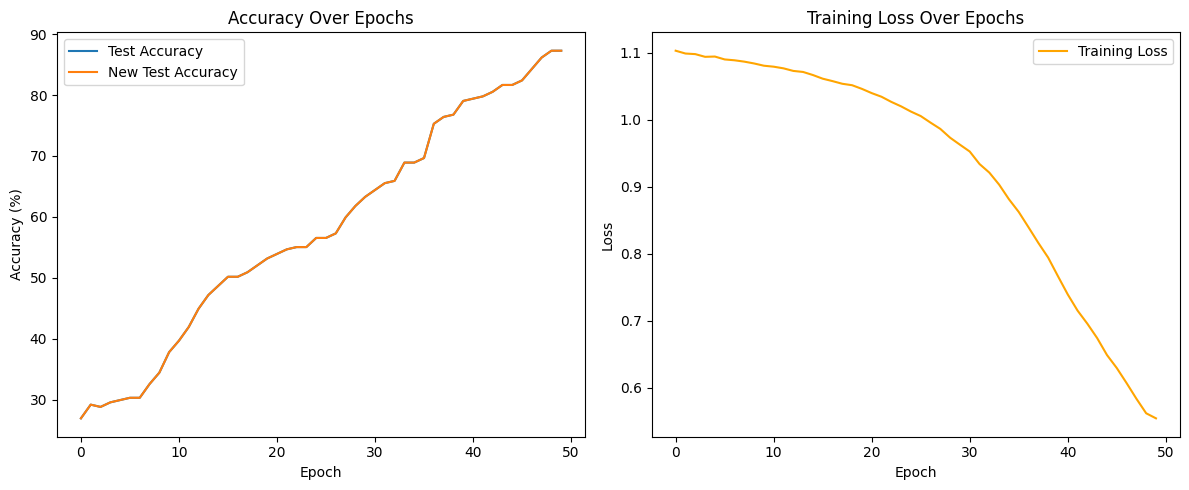

Test Accuracy: 87.27% | Loss: 0.568755


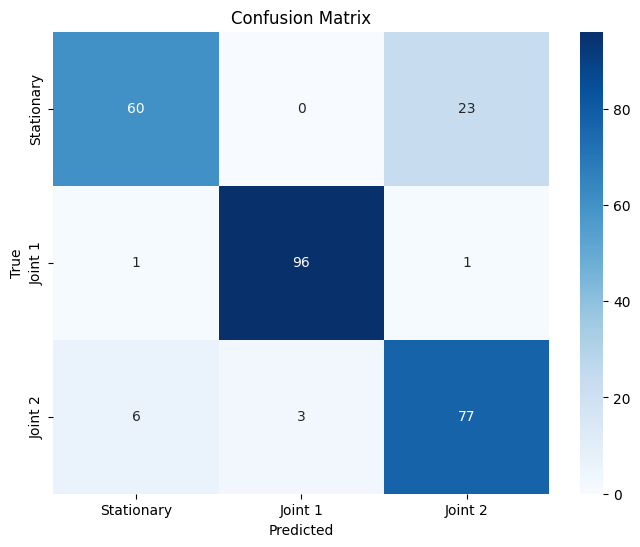


Classification Report for Test Set:
              precision    recall  f1-score   support

  Stationary       0.90      0.72      0.80        83
     Joint 1       0.97      0.98      0.97        98
     Joint 2       0.76      0.90      0.82        86

    accuracy                           0.87       267
   macro avg       0.88      0.87      0.87       267
weighted avg       0.88      0.87      0.87       267


Starting learning rate experiment...

Training with learning rate: 0.001
Test (LR=0.001) Accuracy: 36.70% | Loss: 1.095484
Test (LR=0.001) Accuracy: 36.70% | Loss: 1.095441
Test (LR=0.001) Accuracy: 36.70% | Loss: 1.095823
Test (LR=0.001) Accuracy: 36.70% | Loss: 1.096244
Test (LR=0.001) Accuracy: 36.70% | Loss: 1.096578
Test (LR=0.001) Accuracy: 36.70% | Loss: 1.096835
Test (LR=0.001) Accuracy: 37.08% | Loss: 1.097147
Test (LR=0.001) Accuracy: 37.08% | Loss: 1.097388
Test (LR=0.001) Accuracy: 36.70% | Loss: 1.097556
Test (LR=0.001) Accuracy: 36.70% | Loss: 1.097611

Trainin

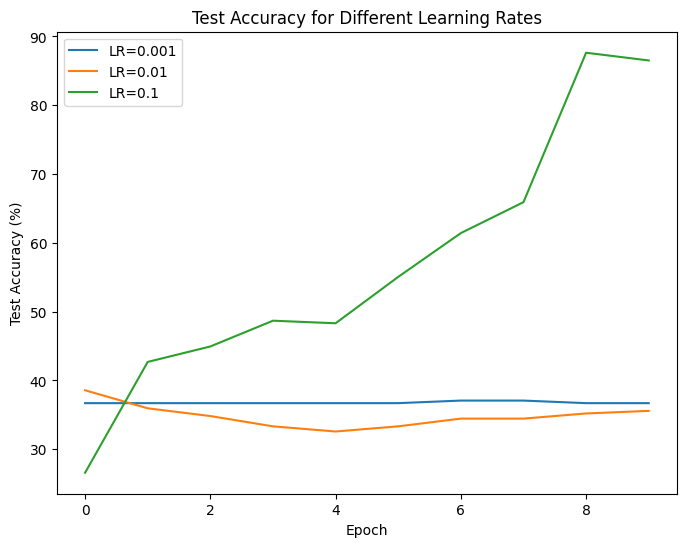

In [ ]:
import pandas as pd #xAi
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
import random
import os
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Set random seed for reproducibility
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(11)

# Custom Dataset
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y, seq_length):
        self.X = torch.from_numpy(X.astype(np.float32))
        self.y = torch.from_numpy(y.astype(np.int64))
        self.seq_length = seq_length
        self.len = X.shape[0]

    def __getitem__(self, index):
        return self.X[index].reshape(1, self.seq_length), self.y[index]

    def __len__(self):
        return self.len

# 1D CNN Model
class TimeSeriesCNN(nn.Module):
    def __init__(self, in_channels=1, input_length=128):
        super(TimeSeriesCNN, self).__init__()
        self.conv1 = nn.Sequential(
            nn.Conv1d(in_channels, 128, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.MaxPool1d(kernel_size=2, stride=3)
        )
        self.conv2 = nn.Sequential(
            nn.Conv1d(128, 32, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.MaxPool1d(kernel_size=2, stride=2)
        )
        self.conv3 = nn.Sequential(
            nn.Conv1d(32, 32, kernel_size=2, stride=2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2)
        )
        self.conv4 = nn.Sequential(
            nn.Conv1d(32, 128, kernel_size=2, stride=1),
            nn.ReLU()
        )
        # Compute flattened size dynamically
        with torch.no_grad():
            dummy = torch.zeros(1, in_channels, input_length)
            out = self.conv1(dummy)
            out = self.conv2(out)
            out = self.conv3(out)
            out = self.conv4(out)
            self.flat_size = out.flatten(start_dim=1).shape[1]
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(self.flat_size, 128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(128, 3)
        )

    def forward(self, x):
        out = self.conv1(x)
        out = self.conv2(out)
        out = self.conv3(out)
        out = self.conv4(out)
        out = self.fc(out)
        return out

# Feature Extraction
def extract_features(df, window_size, overlap):
    if 'y' not in df.columns:
        raise ValueError("DataFrame must contain a 'y' column")
    stride = int(window_size * (1 - overlap))
    windows = []
    for i in range(0, len(df) - window_size + 1, stride):
        window = df['y'].iloc[i:i + window_size].values
        windows.append(window)
    return np.array(windows)

# Data Loading
def load_and_process_data(file_paths, window_size, overlap, label_map):
    Xs, ys = [], []
    for file, label in file_paths.items():
        if not os.path.exists(file):
            raise FileNotFoundError(f"File {file} not found")
        df = pd.read_csv(file, header=0)
        X = extract_features(df, window_size, overlap)
        y = np.full(len(X), label, dtype=np.int64)
        Xs.append(X)
        ys.append(y)
    X = np.concatenate(Xs, axis=0)
    y = np.concatenate(ys, axis=0)
    return X, y

# Training Function
def train_model(model, train_loader, criterion, optimizer, epoch):
    model.train()
    running_loss = 0.0
    total_batches = len(train_loader)
    for batch_idx, (inputs, targets) in enumerate(train_loader):
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        if batch_idx % 10 == 9:
            print(f'[Epoch {epoch + 1}, Batch {batch_idx + 1}] Loss: {running_loss / 10:.6f}')
            running_loss = 0.0
    avg_loss = running_loss / (total_batches % 10 or total_batches)
    return avg_loss

# Evaluation Function
def evaluate_model(model, test_loader, criterion, dataset_name="Test"):
    model.eval()
    correct, total = 0, 0
    all_preds, all_labels = [], []
    running_loss = 0.0
    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted = torch.max(outputs, dim=1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    accuracy = 100 * correct / total
    avg_loss = running_loss / len(test_loader)
    print(f'{dataset_name} Accuracy: {accuracy:.2f}% | Loss: {avg_loss:.6f}')
    return accuracy, avg_loss, all_preds, all_labels

# Main Execution
def main():
    # Configuration
    window_size = 128
    overlap = 0.97
    batch_size = 144
    epochs = 50
    learning_rates = [0.001, 0.01, 0.1]

    # Load data
    original_files = {
        'air.csv': 0,  # Stationary
        '2t.csv': 1,   # Joint 1
        '5t.csv': 2    # Joint 2
    }
    new_files = {
        'airnew.csv': 0,
        '2tnew.csv': 1,
        '5tnew.csv': 2
    }

    print("Loading original dataset...")
    X, y = load_and_process_data(original_files, window_size, overlap, original_files)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.33, random_state=26, stratify=y
    )

    print("Loading new dataset...")
    X_new, y_new = load_and_process_data(new_files, window_size, overlap, new_files)
    X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
        X_new, y_new, test_size=0.33, random_state=26, stratify=y_new
    )

    # Create DataLoaders
    train_dataset = TimeSeriesDataset(X_train, y_train, window_size)
    test_dataset = TimeSeriesDataset(X_test, y_test, window_size)
    train_dataset_new = TimeSeriesDataset(X_train_new, y_train_new, window_size)
    test_dataset_new = TimeSeriesDataset(X_test_new, y_test_new, window_size)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    train_loader_new = DataLoader(train_dataset_new, batch_size=batch_size, shuffle=True)
    test_loader_new = DataLoader(test_dataset_new, batch_size=batch_size, shuffle=False)

    # Verify DataLoader
    for batch_idx, (X, y) in enumerate(train_loader):
        print(f"Batch {batch_idx + 1}: X shape = {X.shape}, y shape = {y.shape}")
        break

    # Single Learning Rate Training
    print("\nTraining with single learning rate (0.01)...")
    model = TimeSeriesCNN(input_length=window_size)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.01)
    train_losses, test_accuracies, test_new_accuracies = [], [], []

    for epoch in range(epochs):
        train_loss = train_model(model, train_loader, criterion, optimizer, epoch)
        test_acc, test_loss, _, _ = evaluate_model(model, test_loader, criterion, "Test")
        test_new_acc, test_new_loss, _, _ = evaluate_model(model, test_loader_new, criterion, "New Test")
        train_losses.append(train_loss)
        test_accuracies.append(test_acc)
        test_new_accuracies.append(test_new_acc)

    # Plot Accuracy and Loss
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(test_accuracies, label='Test Accuracy')
    plt.plot(test_new_accuracies, label='New Test Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.title('Accuracy Over Epochs')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(train_losses, label='Training Loss', color='orange')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Loss Over Epochs')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Confusion Matrix
    _, _, preds, labels = evaluate_model(model, test_loader, criterion, "Test")
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Stationary', 'Joint 1', 'Joint 2'],
                yticklabels=['Stationary', 'Joint 1', 'Joint 2'])
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

    # Classification Report
    print("\nClassification Report for Test Set:")
    print(classification_report(labels, preds, target_names=['Stationary', 'Joint 1', 'Joint 2']))

    # Learning Rate Experiment
    print("\nStarting learning rate experiment...")
    all_test_accuracies = []
    for lr in learning_rates:
        print(f"\nTraining with learning rate: {lr}")
        model = TimeSeriesCNN(input_length=window_size)
        optimizer = optim.SGD(model.parameters(), lr=lr)
        criterion = nn.CrossEntropyLoss()
        test_accuracies_lr = []
        for epoch in range(10):  # Reduced for quick experimentation
            train_model(model, train_loader, criterion, optimizer, epoch)
            acc, _, _, _ = evaluate_model(model, test_loader, criterion, f"Test (LR={lr})")
            test_accuracies_lr.append(acc)
        all_test_accuracies.append(test_accuracies_lr)

    # Plot Learning Rate Experiment
    plt.figure(figsize=(8, 6))
    for i, lr in enumerate(learning_rates):
        plt.plot(all_test_accuracies[i], label=f'LR={lr}')
    plt.xlabel('Epoch')
    plt.ylabel('Test Accuracy (%)')
    plt.title('Test Accuracy for Different Learning Rates')
    plt.legend()
    plt.show()



Batch: 1
X shape: torch.Size([144, 128, 1])
y shape: torch.Size([144])
Using device: cpu
Epoch 1, Avg Loss: 1.09826747
Accuracy on test set: 47.57%
Accuracy on new test set: 47.57%
Epoch 2, Avg Loss: 1.09651011
Accuracy on test set: 38.58%
Accuracy on new test set: 38.58%
Epoch 3, Avg Loss: 1.09707776
Accuracy on test set: 36.70%
Accuracy on new test set: 36.70%
Epoch 4, Avg Loss: 1.09592089
Accuracy on test set: 37.08%
Accuracy on new test set: 37.08%
Epoch 5, Avg Loss: 1.09657240
Accuracy on test set: 37.08%
Accuracy on new test set: 37.08%
Epoch 6, Avg Loss: 1.09600002
Accuracy on test set: 36.70%
Accuracy on new test set: 36.70%
Epoch 7, Avg Loss: 1.09452128
Accuracy on test set: 36.70%
Accuracy on new test set: 36.70%
Epoch 8, Avg Loss: 1.09498146
Accuracy on test set: 36.70%
Accuracy on new test set: 36.70%
Epoch 9, Avg Loss: 1.09463814
Accuracy on test set: 36.70%
Accuracy on new test set: 36.70%
Epoch 10, Avg Loss: 1.09533823
Accuracy on test set: 36.70%
Accuracy on new test se

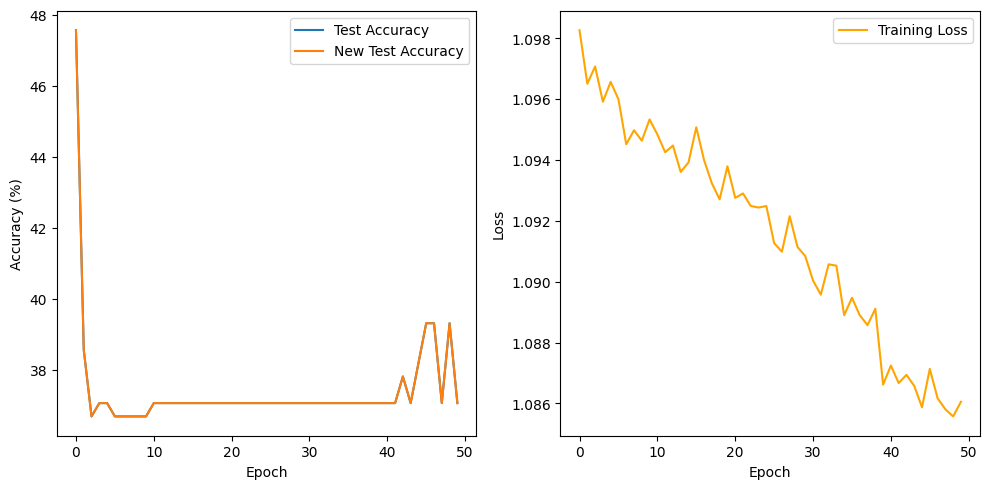

Accuracy on test set: 37.08%


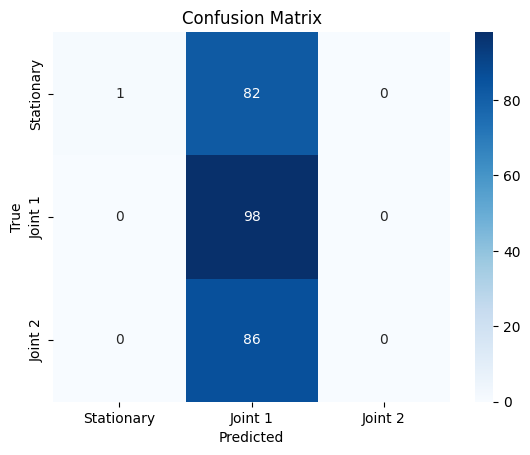

Accuracy on test set: 37.08%
Classification Report:
              precision    recall  f1-score   support

  Stationary       1.00      0.01      0.02        83
     Joint 1       0.37      1.00      0.54        98
     Joint 2       0.00      0.00      0.00        86

    accuracy                           0.37       267
   macro avg       0.46      0.34      0.19       267
weighted avg       0.45      0.37      0.21       267


Training with learning rate: 0.001
Epoch 1, Avg Loss: 1.10265657
Accuracy on test (lr=0.001) set: 31.09%
Epoch 2, Avg Loss: 1.10151505
Accuracy on test (lr=0.001) set: 31.09%
Epoch 3, Avg Loss: 1.10178059
Accuracy on test (lr=0.001) set: 31.09%
Epoch 4, Avg Loss: 1.10078344
Accuracy on test (lr=0.001) set: 31.09%
Epoch 5, Avg Loss: 1.10131440
Accuracy on test (lr=0.001) set: 31.09%
Epoch 6, Avg Loss: 1.09995762
Accuracy on test (lr=0.001) set: 31.09%
Epoch 7, Avg Loss: 1.10023037
Accuracy on test (lr=0.001) set: 31.09%
Epoch 8, Avg Loss: 1.10194755
Accuracy on

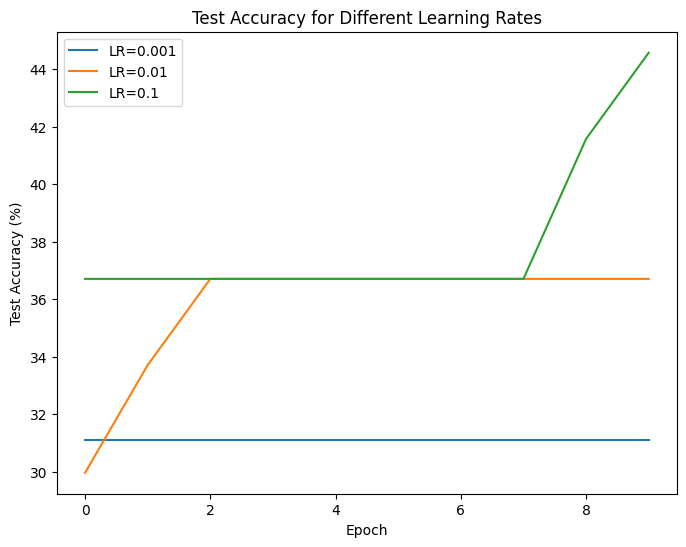

In [ ]:
import math #RNN
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch
from torch import nn, optim
import random
from torch.utils.data import Dataset, DataLoader
import warnings
import os
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

warnings.filterwarnings("ignore")

# Set random seed for reproducibility
def setup_seed(seed):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True

setup_seed(11)

# Convert data to torch tensors
class Data(Dataset):
    def __init__(self, X, y, seq_length=128):
        self.X = torch.from_numpy(X.astype(np.float32))
        self.y = torch.from_numpy(y.astype(np.int64))
        self.seq_length = seq_length
        self.len = self.X.shape[0]

    def __getitem__(self, index):
        # Reshape to (seq_length, 1) for RNN input
        return self.X[index].reshape(self.seq_length, 1), self.y[index]

    def __len__(self):
        return self.len

# RNN-based classifier
class RNNClassifier(nn.Module):
    def __init__(self, input_size=1, hidden_size=128, num_layers=2, output_size=3):
        super(RNNClassifier, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        # LSTM layer
        self.rnn = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2 if num_layers > 1 else 0
        )
        # Fully connected layers
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 128),
            nn.ReLU(),
            nn.Dropout(p=0.1),
            nn.Linear(128, output_size)
        )

    def forward(self, x):
        # x shape: (batch, seq_length, input_size)
        batch_size = x.size(0)
        # Initialize hidden state
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(x.device)
        # Forward pass through RNN
        out, _ = self.rnn(x, (h0, c0))
        # Take the output from the last time step
        out = out[:, -1, :]
        # Pass through fully connected layers
        out = self.fc(out)
        return out

def feature_extraction(df, length, overlap):
    if 'y' not in df.columns:
        raise ValueError("DataFrame must contain a 'y' column")
    processed_df = []
    stride = int(length * (1 - overlap))
    for i in range(0, len(df) - length + 1, stride):
        signal = df['y'].iloc[i:i + length].values
        processed_df.append(signal)
    return np.array(processed_df)

# Load data from csv files
def load_data(file_paths, data_length, overlap_rate):
    Xs, ys = [], []
    for file, label in file_paths.items():
        if not os.path.exists(file):
            raise FileNotFoundError(f"File {file} not found")
        df = pd.read_csv(file, header=0)
        X = feature_extraction(df, data_length, overlap_rate)
        y = np.full(len(X), label, dtype=np.int64)
        Xs.append(X)
        ys.append(y)
    X = np.concatenate(Xs, axis=0)
    y = np.concatenate(ys, axis=0)
    return X, y

# Divide tables into data samples
data_length = 128
overlap_rate = 0.97
batch_size = 144

original_files = {
    'air.csv': 0,  # Stationary
    '2t.csv': 1,   # Joint 1
    '5t.csv': 2    # Joint 2
}
new_files = {
    'airnew.csv': 0,
    '2tnew.csv': 1,
    '5tnew.csv': 2
}

# Load and split original data
X, y = load_data(original_files, data_length, overlap_rate)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=26, stratify=y
)

# Load and split new data
X_new, y_new = load_data(new_files, data_length, overlap_rate)
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_new, y_new, test_size=0.33, random_state=26, stratify=y
)

# Instantiate training and test data
train_data = Data(X_train, y_train, data_length)
train_dataloader = DataLoader(dataset=train_data, batch_size=batch_size, shuffle=True)
test_data = Data(X_test, y_test, data_length)
test_dataloader = DataLoader(dataset=test_data, batch_size=batch_size, shuffle=False)
train_data_new = Data(X_train_new, y_train_new, data_length)
train_dataloader_new = DataLoader(dataset=train_data_new, batch_size=batch_size, shuffle=True)
test_data_new = Data(X_test_new, y_test_new, data_length)
test_dataloader_new = DataLoader(dataset=test_data_new, batch_size=batch_size, shuffle=False)

# Check DataLoader
for batch, (X, y) in enumerate(train_dataloader):
    print(f"Batch: {batch + 1}")
    print(f"X shape: {X.shape}")
    print(f"y shape: {y.shape}")
    break

# Training function
def train(epoch, model, train_loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    total_batches = len(train_loader)
    for batch_idx, (inputs, target) in enumerate(train_loader, 0):
        inputs, target = inputs.to(device), target.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, target)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        if batch_idx % 10 == 9:
            print(f'[{epoch + 1}, {batch_idx + 1:5d}] loss: {running_loss / 10:.8f}')
            running_loss = 0.0
    avg_loss = running_loss / (total_batches % 10 or total_batches)
    print(f'Epoch {epoch + 1}, Avg Loss: {avg_loss:.8f}')
    return avg_loss

# Test function
def test(model, test_loader, criterion, dataset_name="test"):
    model.eval()
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, dim=1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    accuracy = 100 * correct / total
    print(f'Accuracy on {dataset_name} set: {accuracy:.2f}%')
    return accuracy, all_preds, all_labels

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Initialize model, loss, and optimizer
model = RNNClassifier().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

# Lists to store metrics
train_losses = []
correct_list = []

# Original training loop
for epoch in range(50):
    train_loss = train(epoch, model, train_dataloader, criterion, optimizer)
    test_acc, _, _ = test(model, test_dataloader, criterion, "test")
    test_new_acc, _, _ = test(model, test_dataloader_new, criterion, "new test")
    train_losses.append(train_loss)
    correct_list.append(test_acc)
    correct_list.append(test_new_acc)

# Plot accuracy and loss
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(correct_list[::2], label='Test Accuracy')
plt.plot(correct_list[1::2], label='New Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(train_losses, label='Training Loss', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

# Confusion matrix
def test_with_confusion(model, test_loader):
    _, preds, labels = test(model, test_loader, criterion, "test")
    cm = confusion_matrix(labels, preds)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Stationary', 'Joint 1', 'Joint 2'],
        yticklabels=['Stationary', 'Joint 1', 'Joint 2']
    )
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

test_with_confusion(model, test_dataloader)

# Classification report
def test_with_metrics(model, test_loader):
    _, preds, labels = test(model, test_loader, criterion, "test")
    print("Classification Report:")
    print(classification_report(labels, preds, target_names=['Stationary', 'Joint 1', 'Joint 2']))

test_with_metrics(model, test_dataloader)

# Learning rate experiment
learning_rates = [0.001, 0.01, 0.1]
all_correct_lists = []

for lr in learning_rates:
    print(f"\nTraining with learning rate: {lr}")
    model = RNNClassifier().to(device)
    optimizer = optim.SGD(model.parameters(), lr=lr)
    correct_list = []
    train_losses = []
    for epoch in range(10):
        train_loss = train(epoch, model, train_dataloader, criterion, optimizer)
        test_acc, _, _ = test(model, test_dataloader, criterion, f"test (lr={lr})")
        # Optionally include new test set
        # test_new_acc, _, _ = test(model, test_dataloader_new, criterion, f"new test (lr={lr})")
        correct_list.append(test_acc)
        train_losses.append(train_loss)
    all_correct_lists.append(correct_list)

# Plot learning rate experiment
plt.figure(figsize=(8, 6))
for i, lr in enumerate(learning_rates):
    plt.plot(all_correct_lists[i], label=f'LR={lr}')
plt.xlabel('Epoch')
plt.ylabel('Test Accuracy (%)')
plt.title('Test Accuracy for Different Learning Rates')
plt.legend()
plt.show()


Batch: 1
X shape: torch.Size([144, 128, 1])
y shape: torch.Size([144])
Epoch 1, Avg Loss: 1.17250401
Accuracy on test set: 32 %
Accuracy on new test set: 32 %
Epoch 2, Avg Loss: 1.13646203
Accuracy on test set: 30 %
Accuracy on new test set: 25 %
Epoch 3, Avg Loss: 1.11170560
Accuracy on test set: 30 %
Accuracy on new test set: 29 %
Epoch 4, Avg Loss: 1.10128537
Accuracy on test set: 33 %
Accuracy on new test set: 28 %
Epoch 5, Avg Loss: 1.10326099
Accuracy on test set: 33 %
Accuracy on new test set: 32 %
Epoch 6, Avg Loss: 1.09306762
Accuracy on test set: 33 %
Accuracy on new test set: 32 %
Epoch 7, Avg Loss: 1.08789563
Accuracy on test set: 34 %
Accuracy on new test set: 32 %
Epoch 8, Avg Loss: 1.08014709
Accuracy on test set: 34 %
Accuracy on new test set: 32 %
Epoch 9, Avg Loss: 1.08192384
Accuracy on test set: 37 %
Accuracy on new test set: 37 %
Epoch 10, Avg Loss: 1.08469144
Accuracy on test set: 39 %
Accuracy on new test set: 35 %
Epoch 11, Avg Loss: 1.08394587
Accuracy on test 

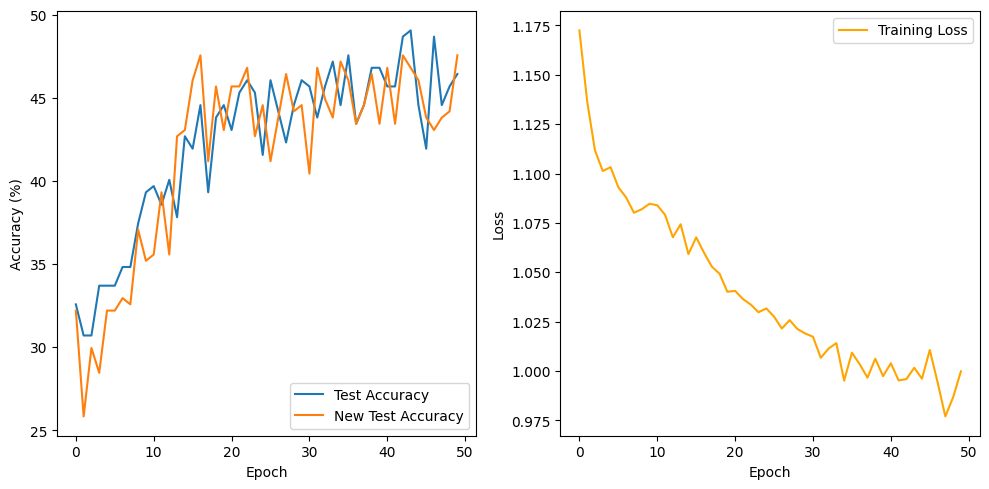

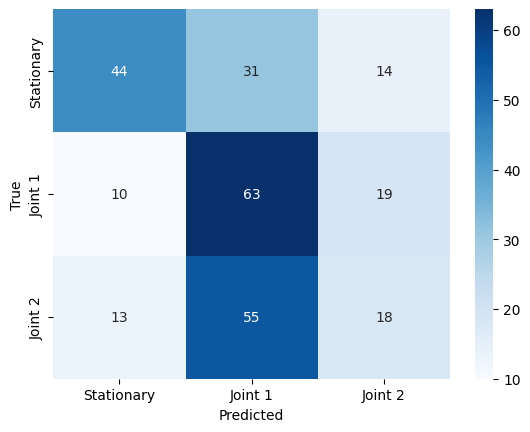

              precision    recall  f1-score   support

  Stationary       0.58      0.42      0.48        89
     Joint 1       0.42      0.72      0.53        92
     Joint 2       0.29      0.15      0.20        86

    accuracy                           0.43       267
   macro avg       0.43      0.43      0.40       267
weighted avg       0.43      0.43      0.41       267


Training with learning rate: 0.001
Epoch 1, Avg Loss: 1.07717288
Accuracy on test set: 44 %
Epoch 2, Avg Loss: 1.09323019
Accuracy on test set: 40 %
Epoch 3, Avg Loss: 1.08454171
Accuracy on test set: 35 %
Epoch 4, Avg Loss: 1.08152863
Accuracy on test set: 42 %
Epoch 5, Avg Loss: 1.08174840
Accuracy on test set: 43 %
Epoch 6, Avg Loss: 1.07819384
Accuracy on test set: 42 %
Epoch 7, Avg Loss: 1.07791302
Accuracy on test set: 39 %
Epoch 8, Avg Loss: 1.07395312
Accuracy on test set: 42 %
Epoch 9, Avg Loss: 1.07823107
Accuracy on test set: 38 %
Epoch 10, Avg Loss: 1.07554647
Accuracy on test set: 44 %

Training wi

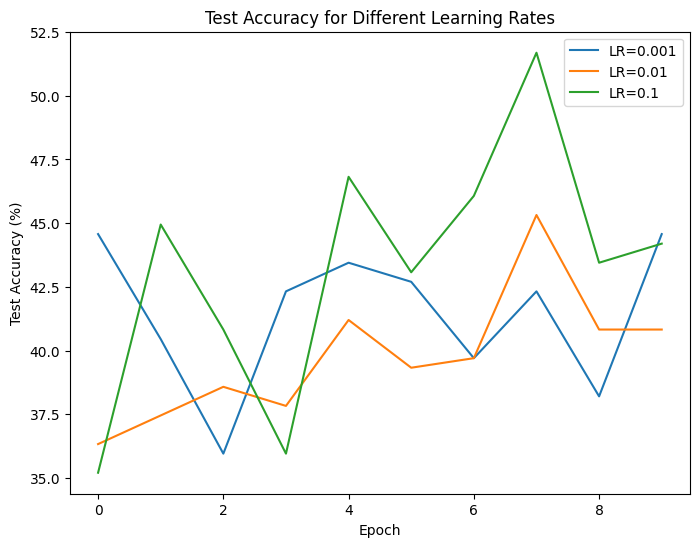

In [ ]:
import math #Transformer version 3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
import torch
from torch import nn
from torch import optim
import random
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import warnings
warnings.filterwarnings("ignore")

# Convert data to torch tensors
class Data(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X.astype(np.float32))
        self.y = torch.from_numpy(y.astype(np.float32))
        self.len = self.X.shape[0]

    def __getitem__(self, index):
        # Reshape to (seq_length, 1) for Transformer input
        return self.X[index].reshape(128, 1), self.y[index].long()

    def __len__(self):
        return self.len

# Transformer-based classifier
class classifier(nn.Module):
    def __init__(self, input_size=1, d_model=64, nhead=4, num_layers=2):
        super(classifier, self).__init__()
        self.input_proj = nn.Linear(input_size, d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=128,
            dropout=0.1,
            activation='relu',
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.sq7 = nn.Sequential(
            nn.Linear(d_model, 128),
            nn.ReLU(),
            nn.Dropout(p=0.1),
            nn.Linear(128, 3)
        )

    def forward(self, x, ex_features=None):
        # x: (batch, seq_length, input_size)
        x = self.input_proj(x)  # (batch, seq_length, d_model)
        out = self.transformer(x)  # (batch, seq_length, d_model)
        out = out[:, -1, :]  # Take last time step
        out = self.sq7(out)  # (batch, 3)
        return out

def feature_extraction(df, length, overlap):
    processed_df = []
    i = 0
    while i < (len(df) - length):
        if i % math.floor(length * (1 - overlap)) == 0:
            features = []
            signal = df['y'][i:i + length]
            features.extend(signal)
            processed_df.append(features)
        i = i + 1
    processed_df = np.array(processed_df)
    return processed_df

def setup_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True

# Setting random seeds
setup_seed(11)

# Divide tables into data samples
data_length = 128
overlap_rate = 0.97
batch_size = 144

# Load data from csv files
joint_1_table = pd.read_csv('2t.csv', header=0)
joint_2_table = pd.read_csv('5t.csv', header=0)
stationary_table = pd.read_csv('air.csv', header=0)

joint_1_x = feature_extraction(joint_1_table, data_length, overlap_rate)
joint_2_x = feature_extraction(joint_2_table, data_length, overlap_rate)
stationary_x = feature_extraction(stationary_table, data_length, overlap_rate)
X = np.concatenate((stationary_x, joint_1_x, joint_2_x), axis=0)
y = np.concatenate((np.zeros(len(stationary_x)), np.ones(len(joint_1_x)), np.full(len(joint_2_x), 2)), axis=0)
y = y.astype(np.int64)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.33, random_state=26)

# Instantiate training and test data
train_data = Data(X_train, y_train)
train_dataloader = DataLoader(dataset=train_data, batch_size=batch_size, shuffle=True)

test_data = Data(X_test, y_test)
test_dataloader = DataLoader(dataset=test_data, batch_size=batch_size, shuffle=True)

# Load data from csv files
joint_1_table_new = pd.read_csv('2tnew.csv', header=0)
joint_2_table_new = pd.read_csv('5tnew.csv', header=0)
stationary_table_new = pd.read_csv('airnew.csv', header=0)

joint_1_x_new = feature_extraction(joint_1_table_new, data_length, overlap_rate)
joint_2_x_new = feature_extraction(joint_2_table_new, data_length, overlap_rate)
stationary_x_new = feature_extraction(stationary_table_new, data_length, overlap_rate)
X_new = np.concatenate((stationary_x_new, joint_1_x_new, joint_2_x_new), axis=0)
y_new = np.concatenate((np.zeros(len(stationary_x_new)), np.ones(len(joint_1_x_new)), np.full(len(joint_2_x_new), 2)), axis=0)
y_new = y_new.astype(np.int64)
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_new, y_new, test_size=.33, random_state=26)

# Instantiate training and test data
train_data_new = Data(X_train_new, y_train_new)
train_dataloader_new = DataLoader(dataset=train_data_new, batch_size=batch_size, shuffle=True)

test_data_new = Data(X_test_new, y_test_new)
test_dataloader_new = DataLoader(dataset=test_data_new, batch_size=batch_size, shuffle=True)

# Check it's working
for batch, (X, y) in enumerate(train_dataloader):
    print(f"Batch: {batch + 1}")
    print(f"X shape: {X.shape}")
    print(f"y shape: {y.shape}")
    break

# Initialize model, loss, and optimizer
model = classifier()
criterion = torch.nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

# Lists to store metrics
train_losses = []
correct_list = []

def train(epoch):
    running_loss = 0.0
    total_batches = len(train_dataloader)
    for batch_idx, data in enumerate(train_dataloader, 0):
        inputs, target = data
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, target)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        if batch_idx % 10 == 9:
            print('[%d, %5d] loss: %.8f' % (epoch + 1, batch_idx + 1, running_loss / 10))
            running_loss = 0.0
    avg_loss = running_loss / (total_batches % 10 or total_batches)
    train_losses.append(avg_loss)
    print(f'Epoch {epoch + 1}, Avg Loss: {avg_loss:.8f}')

def test():
    correct = 0
    total = 0
    with torch.no_grad():
        for data in test_dataloader:
            inputs, labels = data
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, dim=1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = 100 * correct / total
    correct_list.append(accuracy)
    print('Accuracy on test set: %d %%' % accuracy)

def test_new():
    correct = 0
    total = 0
    with torch.no_grad():
        for data in test_dataloader_new:
            inputs, labels = data
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, dim=1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = 100 * correct / total
    correct_list.append(accuracy)
    print('Accuracy on new test set: %d %%' % accuracy)

# Original training loop (50 epochs with single learning rate)
for epoch in range(50):
    train(epoch)
    test()
    test_new()

# Plot accuracy and loss together
plt.figure(figsize=(10, 5))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(correct_list[::2], label='Test Accuracy')
plt.plot(correct_list[1::2], label='New Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(train_losses, label='Training Loss', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

def test_with_confusion():
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for data in test_dataloader:
            inputs, labels = data
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, dim=1)
            all_preds.extend(predicted.numpy())
            all_labels.extend(labels.numpy())
    cm = confusion_matrix(all_labels, all_preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Stationary', 'Joint 1', 'Joint 2'], yticklabels=['Stationary', 'Joint 1', 'Joint 2'])
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

test_with_confusion()

# Classification report
from sklearn.metrics import classification_report

def test_with_metrics():
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for data in test_dataloader:
            inputs, labels = data
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, dim=1)
            all_preds.extend(predicted.numpy())
            all_labels.extend(labels.numpy())
    print(classification_report(all_labels, all_preds, target_names=['Stationary', 'Joint 1', 'Joint 2']))

test_with_metrics()

# Experiment with different learning rates
learning_rates = [0.001, 0.01, 0.1]
all_correct_lists = []

for lr in learning_rates:
    print(f"\nTraining with learning rate: {lr}")
    model = classifier()
    optimizer = optim.SGD(model.parameters(), lr=lr)
    correct_list = []
    train_losses = []
    for epoch in range(10):
        train(epoch)
        test()
        # test_new()
    all_correct_lists.append(correct_list)

# Plot accuracies for different learning rates
plt.figure(figsize=(8, 6))
for i, lr in enumerate(learning_rates):
    plt.plot(all_correct_lists[i], label=f'LR={lr}')
plt.xlabel('Epoch')
plt.ylabel('Test Accuracy (%)')
plt.title('Test Accuracy for Different Learning Rates')
plt.legend()
plt.show()
if __name__ == "__main__":
    main()

Processing original data:
Extracted 42 samples with augment=True
Extracted 39 samples with augment=True
Extracted 36 samples with augment=True
X shape: (117, 128), y shape: (117,)

Processing new data:
Extracted 14 samples with augment=False
Extracted 13 samples with augment=False
Extracted 12 samples with augment=False
X_new shape: (39, 128), y_new shape: (39,)
Batch: 1
X shape: torch.Size([78, 128, 1])
y shape: torch.Size([78])
Epoch 1, Avg Loss: 1.18072760
Accuracy on test set: 30.77% | Loss: 1.10222960
Accuracy on new test set: 46.15% | Loss: 1.07262826
Epoch 2, Avg Loss: 1.10482764
Accuracy on test set: 46.15% | Loss: 1.06954980
Accuracy on new test set: 53.85% | Loss: 1.04099584
Epoch 3, Avg Loss: 1.09189200
Accuracy on test set: 58.97% | Loss: 1.05747342
Accuracy on new test set: 69.23% | Loss: 1.02730262
Epoch 4, Avg Loss: 1.06315303
Accuracy on test set: 51.28% | Loss: 1.05225861
Accuracy on new test set: 61.54% | Loss: 1.01925719
Epoch 5, Avg Loss: 1.05141306
Accuracy on test

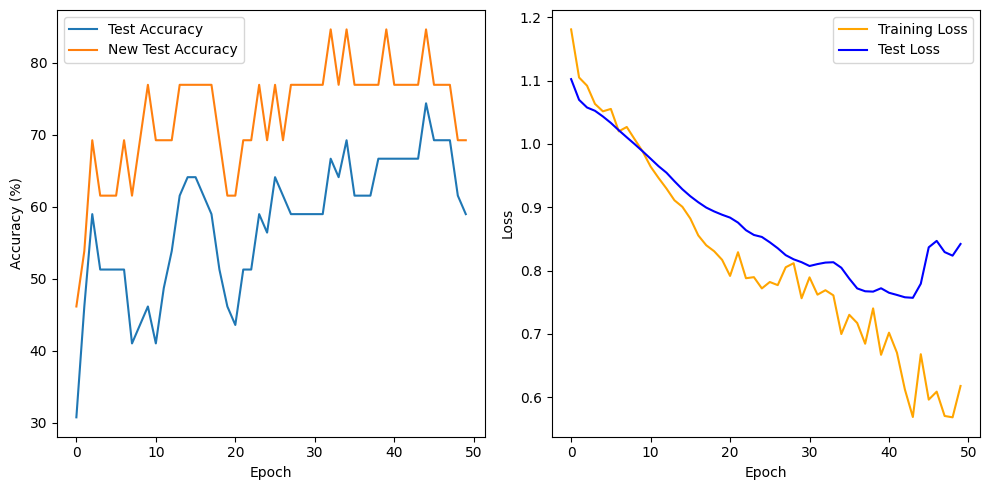

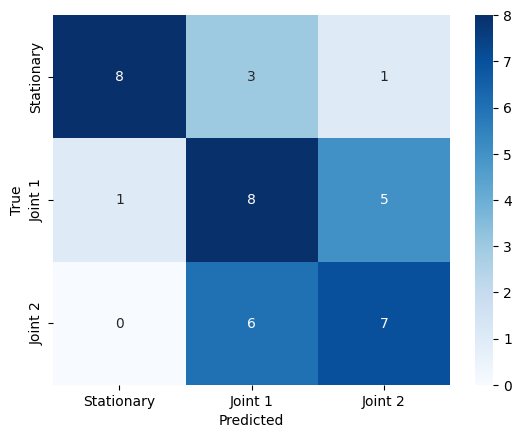

              precision    recall  f1-score   support

  Stationary       0.89      0.67      0.76        12
     Joint 1       0.47      0.57      0.52        14
     Joint 2       0.54      0.54      0.54        13

    accuracy                           0.59        39
   macro avg       0.63      0.59      0.61        39
weighted avg       0.62      0.59      0.60        39


Training with learning rate: 0.001
Epoch 1, Avg Loss: 1.11083353
Accuracy on test set: 28.21% | Loss: 1.09674704
Epoch 2, Avg Loss: 1.11859596
Accuracy on test set: 48.72% | Loss: 1.07826912
Epoch 3, Avg Loss: 1.07988501
Accuracy on test set: 48.72% | Loss: 1.06264436
Epoch 4, Avg Loss: 1.06964469
Accuracy on test set: 51.28% | Loss: 1.04836190
Epoch 5, Avg Loss: 1.08530033
Accuracy on test set: 58.97% | Loss: 1.03383374
Epoch 6, Avg Loss: 1.05792665
Accuracy on test set: 58.97% | Loss: 1.02136385
Epoch 7, Avg Loss: 1.04368556
Accuracy on test set: 58.97% | Loss: 1.00790381
Epoch 8, Avg Loss: 1.02136517
Accurac

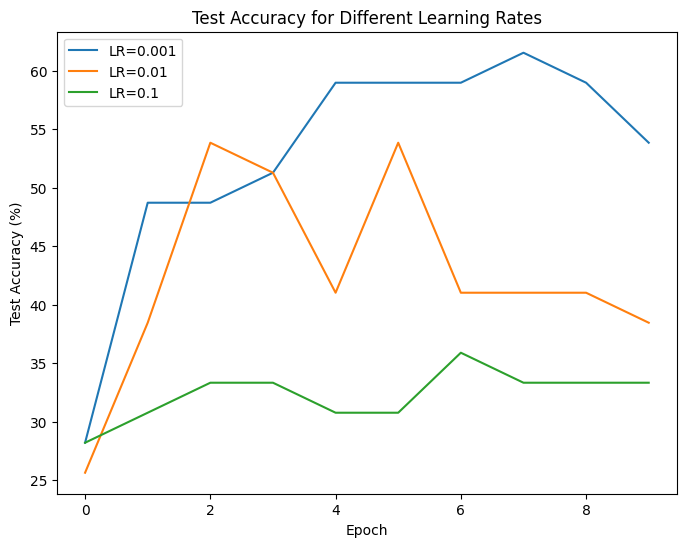

In [ ]:
import math #Modified transformer code
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
import torch
from torch import nn
from torch import optim
import random
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import warnings
warnings.filterwarnings("ignore")

# Convert data to torch tensors
class Data(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X.astype(np.float32))
        self.y = torch.from_numpy(y.astype(np.float32))
        self.len = self.X.shape[0]

    def __getitem__(self, index):
        return self.X[index].reshape(128, 1), self.y[index].long()

    def __len__(self):
        return self.len

# Transformer-based classifier
class classifier(nn.Module):
    def __init__(self, input_size=1):
        super(classifier, self).__init__()
        self.input_proj = nn.Linear(input_size, 64)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=64,
            nhead=4,
            dim_feedforward=128,
            dropout=0.2,
            activation='relu',
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.sq7 = nn.Sequential(
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(128, 3)
        )

    def forward(self, x, ex_features=None):
        x = self.input_proj(x)
        out = self.transformer(x)
        out = out[:, -1, :]
        out = self.sq7(out)
        return out

# Modified feature extraction with validation
def feature_extraction(df, length, overlap, augment=False):
    if 'y' not in df.columns:
        raise ValueError("DataFrame must contain 'y' column")
    if len(df) < length:
        raise ValueError(f"DataFrame has {len(df)} rows, need at least {length}")
    from sklearn.preprocessing import StandardScaler
    processed_df = []
    scaler = StandardScaler()
    signal = scaler.fit_transform(df[['y']].values).flatten()
    i = 0
    stride = math.floor(length * (1 - overlap))
    while i < (len(signal) - length):
        if i % stride == 0:
            features = signal[i:i + length]
            processed_df.append(features)
            if augment:
                noise = np.random.normal(0, 0.01, length)
                processed_df.append(features + noise)
                processed_df.append(features * np.random.uniform(0.9, 1.1))
        i += 1
    result = np.array(processed_df)
    print(f"Extracted {len(result)} samples with augment={augment}")
    return result

def setup_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True

# Setting random seeds
setup_seed(11)

# Divide tables into data samples
data_length = 128
overlap_rate = 0.5
batch_size = 144

# Load and process original data
joint_1_table = pd.read_csv('2t.csv', header=0)
joint_2_table = pd.read_csv('5t.csv', header=0)
stationary_table = pd.read_csv('air.csv', header=0)

print("Processing original data:")
joint_1_x = feature_extraction(joint_1_table, data_length, overlap_rate, augment=True)
joint_2_x = feature_extraction(joint_2_table, data_length, overlap_rate, augment=True)
stationary_x = feature_extraction(stationary_table, data_length, overlap_rate, augment=True)
X = np.concatenate((stationary_x, joint_1_x, joint_2_x), axis=0)
y = np.concatenate((np.zeros(len(stationary_x)), np.ones(len(joint_1_x)), np.full(len(joint_2_x), 2)), axis=0)
y = y.astype(np.int64)
print(f"X shape: {X.shape}, y shape: {y.shape}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=26, stratify=y)

# Instantiate training and test data
train_data = Data(X_train, y_train)
train_dataloader = DataLoader(dataset=train_data, batch_size=batch_size, shuffle=True)
test_data = Data(X_test, y_test)
test_dataloader = DataLoader(dataset=test_data, batch_size=batch_size, shuffle=False)

# Load and process new data
joint_1_table_new = pd.read_csv('2tnew.csv', header=0)
joint_2_table_new = pd.read_csv('5tnew.csv', header=0)
stationary_table_new = pd.read_csv('airnew.csv', header=0)

print("\nProcessing new data:")
joint_1_x_new = feature_extraction(joint_1_table_new, data_length, overlap_rate, augment=False)
joint_2_x_new = feature_extraction(joint_2_table_new, data_length, overlap_rate, augment=False)
stationary_x_new = feature_extraction(stationary_table_new, data_length, overlap_rate, augment=False)
X_new = np.concatenate((stationary_x_new, joint_1_x_new, joint_2_x_new), axis=0)
y_new = np.concatenate((np.zeros(len(stationary_x_new)), np.ones(len(joint_1_x_new)), np.full(len(joint_2_x_new), 2)), axis=0)
y_new = y_new.astype(np.int64)
print(f"X_new shape: {X_new.shape}, y_new shape: {y_new.shape}")

# Validate lengths
if len(X_new) != len(y_new):
    raise ValueError(f"Mismatch: X_new has {len(X_new)} samples, y_new has {len(y_new)} samples")

X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_new, y_new, test_size=0.33, random_state=26, stratify=y_new)

# Instantiate training and test data
train_data_new = Data(X_train_new, y_train_new)
train_dataloader_new = DataLoader(dataset=train_data_new, batch_size=batch_size, shuffle=True)
test_data_new = Data(X_test_new, y_test_new)
test_dataloader_new = DataLoader(dataset=test_data_new, batch_size=batch_size, shuffle=False)

# Check it's working
for batch, (X, y) in enumerate(train_dataloader):
    print(f"Batch: {batch + 1}")
    print(f"X shape: {X.shape}")
    print(f"y shape: {y.shape}")
    break

# Initialize model, loss, and optimizer
model = classifier()
criterion = torch.nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# Lists to store metrics
train_losses = []
test_losses = []
correct_list = []

def train(epoch):
    model.train()
    running_loss = 0.0
    total_batches = len(train_dataloader)
    for batch_idx, data in enumerate(train_dataloader, 0):
        inputs, target = data
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, target)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        if batch_idx % 10 == 9:
            print('[%d, %5d] loss: %.8f' % (epoch + 1, batch_idx + 1, running_loss / 10))
            running_loss = 0.0
    avg_loss = running_loss / (total_batches % 10 or total_batches)
    train_losses.append(avg_loss)
    print(f'Epoch {epoch + 1}, Avg Loss: {avg_loss:.8f}')
    return avg_loss

def test(dataset_name="test"):
    model.eval()
    correct = 0
    total = 0
    running_loss = 0.0
    loader = test_dataloader if dataset_name == "test" else test_dataloader_new
    with torch.no_grad():
        for data in loader:
            inputs, labels = data
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, dim=1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = 100 * correct / total
    avg_loss = running_loss / len(loader)
    if dataset_name == "test":
        test_losses.append(avg_loss)
    print(f'Accuracy on {dataset_name} set: {accuracy:.2f}% | Loss: {avg_loss:.8f}')
    return accuracy, avg_loss

# Early stopping logic
class EarlyStopping:
    def __init__(self, patience=7, delta=0):
        self.patience = patience
        self.delta = delta
        self.best_loss = float('inf')
        self.counter = 0
        self.best_model = None
        self.early_stop = False

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.delta:
            self.best_loss = val_loss
            self.counter = 0
            self.best_model = model.state_dict()
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

early_stopping = EarlyStopping(patience=7)

# Modified training loop with early stopping
max_epochs = 50
for epoch in range(max_epochs):
    train_loss = train(epoch)
    test_acc, test_loss = test("test")
    test_new_acc, _ = test("new test")
    correct_list.append(test_acc)
    correct_list.append(test_new_acc)
    scheduler.step(test_loss)
    early_stopping(test_loss, model)
    if early_stopping.early_stop:
        print("Early stopping triggered")
        model.load_state_dict(early_stopping.best_model)
        break

# Plot accuracy and loss together
plt.figure(figsize=(10, 5))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(correct_list[::2], label='Test Accuracy')
plt.plot(correct_list[1::2], label='New Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(train_losses, label='Training Loss', color='orange')
plt.plot(test_losses, label='Test Loss', color='blue')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

def test_with_confusion():
    all_preds = []
    all_labels = []
    model.eval()
    with torch.no_grad():
        for data in test_dataloader:
            inputs, labels = data
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, dim=1)
            all_preds.extend(predicted.numpy())
            all_labels.extend(labels.numpy())
    cm = confusion_matrix(all_labels, all_preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Stationary', 'Joint 1', 'Joint 2'], yticklabels=['Stationary', 'Joint 1', 'Joint 2'])
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

test_with_confusion()

# Classification report
from sklearn.metrics import classification_report

def test_with_metrics():
    all_preds = []
    all_labels = []
    model.eval()
    with torch.no_grad():
        for data in test_dataloader:
            inputs, labels = data
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, dim=1)
            all_preds.extend(predicted.numpy())
            all_labels.extend(labels.numpy())
    print(classification_report(all_labels, all_preds, target_names=['Stationary', 'Joint 1', 'Joint 2']))

test_with_metrics()

# Experiment with different learning rates
learning_rates = [0.001, 0.01, 0.1]
all_correct_lists = []

for lr in learning_rates:
    print(f"\nTraining with learning rate: {lr}")
    model = classifier()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
    correct_list = []
    train_losses = []
    test_losses = []
    early_stopping = EarlyStopping(patience=7)
    for epoch in range(10):
        train_loss = train(epoch)
        test_acc, test_loss = test("test")
        scheduler.step(test_loss)
        early_stopping(test_loss, model)
        correct_list.append(test_acc)
        if early_stopping.early_stop:
            print("Early stopping triggered")
            model.load_state_dict(early_stopping.best_model)
            break
    all_correct_lists.append(correct_list)

# Plot accuracies for different learning rates
plt.figure(figsize=(8, 6))
for i, lr in enumerate(learning_rates):
    plt.plot(all_correct_lists[i], label=f'LR={lr}')
plt.xlabel('Epoch')
plt.ylabel('Test Accuracy (%)')
plt.title('Test Accuracy for Different Learning Rates')
plt.legend()
plt.show()
if __name__ == "__main__":
    main()